# TP7 - Evaluation Partie 1

Cette 1ère partie du TP est consacrée à l'étude d'un jeu de données simple. Dont la tâche est décrite ci-après. Vous devrez proposer un "cahier d'expérience" qui vous amènera à la définition d'un "modèle final". 

Le fichier `breast_cancer_dev.csv` contient les descriptions de 478 échantillons de tumeurs du sein, décrits par 9 attributs différents, tels que la taille de la tumeur, la texture, la compacité, la symétrie, la dimension fractale, etc. 

La dernière colonne du fichier, contient la classe binaire à prédire:
    + valeur 2 : les tumeurs bénignes
    + valeur 4 : les tumeurs malignes



## Votre cahier d'expériences

Vous devez proposer dans cette partie toutes les expérimentations que vous allez entreprendre pour tenter de mettre au point le meilleur modèle de prédiction possible.

Structurez votre notebook (**alternez cellules markdown puis cellules de codes**) de sorte à ce qu'il puisse être lu comme un compte-rendu de TP et exécuté.

In [172]:
# TODO

import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
tumeur = pd.read_csv('donnees/breast_cancer_dev.csv')
tumeur


,Clump_Thickness,Cell_Size,Cell_Shape,Marginal_Adhesion,Epithelial_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,2,1,1,2,2,1.0,3,1,1,2
1,1,1,2,1,2,2.0,4,2,1,2
2,3,1,2,1,2,1.0,2,1,1,2
3,5,3,2,1,3,1.0,1,1,1,2
4,6,8,8,1,3,4.0,3,7,1,2
...,...,...,...,...,...,...,...,...,...,...
473,5,3,6,1,2,1.0,1,1,1,2
474,5,6,6,8,6,10.0,4,10,4,4
475,1,1,1,1,2,3.0,3,1,1,2
476,5,1,1,1,2,2.0,2,1,1,2


J'ai importer dans un Dataframe `tumeur` les données du fichier `breast_cancer_dev.csv`. (voir ci-dessus)

Extraction des descriptions et des labels de classes dans deux tableaux Numpy pour ensuite pouvoir les réutiliser et faire des test :
- `X` pour la matrice des descriptions (478 x 10) on prend toutes  colonnes et toute les lignes sauf la derniere qui contient la classe
- `y` pour le vecteur des labels de classe (derniere colonne)

In [173]:
X= np.array(tumeur.iloc[:,:-1])
y= np.array(tumeur.iloc[:,-1])
print(X)
print(y)

[[2. 1. 1. ... 3. 1. 1.]
 [1. 1. 2. ... 4. 2. 1.]
 [3. 1. 2. ... 2. 1. 1.]
 ...
 [1. 1. 1. ... 3. 1. 1.]
 [5. 1. 1. ... 2. 1. 1.]
 [7. 8. 7. ... 8. 8. 4.]]
[2 2 2 2 2 2 4 4 2 2 4 4 4 2 2 2 2 4 4 2 2 2 4 2 2 2 2 4 4 2 4 2 4 2 2 2 4
 2 2 2 4 2 4 2 2 4 4 2 4 2 2 4 4 2 4 2 2 2 4 2 4 2 2 2 2 4 2 4 4 4 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 4 4 4 2 2 4 2 2 2 4 2 4 4 4 2 4 4 2 2 2 2 2 4
 2 2 4 4 2 2 2 2 2 2 4 2 2 2 2 2 2 2 4 2 2 4 4 2 2 2 4 4 2 2 4 2 2 4 2 4 4
 4 4 4 2 4 4 2 2 4 2 2 2 4 2 2 4 2 4 2 2 4 4 2 2 2 4 2 2 4 2 4 2 2 2 2 2 4
 2 2 2 2 4 2 2 4 4 2 2 2 4 4 2 2 2 2 2 2 2 4 2 2 4 2 4 4 4 2 2 2 2 2 2 2 2
 2 2 2 2 4 2 4 2 4 2 2 2 2 2 2 4 4 2 4 4 2 2 4 4 2 2 2 2 2 4 2 2 4 2 4 2 4
 4 2 2 2 4 4 4 2 2 2 4 4 4 2 4 2 2 4 2 2 2 2 4 4 2 2 4 2 2 2 2 2 2 4 2 4 4
 2 2 2 2 2 2 2 2 2 4 4 4 4 4 2 2 2 2 2 4 4 2 2 2 4 2 2 4 2 2 2 2 2 2 2 2 4
 4 4 2 2 4 2 4 2 2 2 2 2 4 2 4 2 4 2 2 2 4 2 2 2 4 2 2 2 4 2 4 2 2 4 4 4 2
 2 4 4 2 2 2 4 4 2 2 2 2 4 4 2 4 2 2 4 2 2 2 4 4 2 2 4 2 2 2 4 2 4 4 4 4 2
 2 4 4 4 4 2 2 2 2 

Transformer la matrice X en une matrice binaire Xbin pour pouvoir comparer 

In [174]:
from jwt import encode
from sklearn.preprocessing import OneHotEncoder
encoder= OneHotEncoder()
encoder.fit(X)
Xbin= encoder.transform(X)


Découpage du dataset (`X` et `y`) en deux sous-ensembles de même taille (`X_train`, `X_test`, `y_train`, `y_test`) en utilisant la méthode `train_test_split()` de Scikit-learn

In [175]:
from sklearn.model_selection import train_test_split    
X_train, X_test, y_train, y_test = train_test_split(Xbin, y, train_size=0.5)
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([2, 4]), array([148,  91])), (array([2, 4]), array([166,  73])))

In [176]:
from sklearn import tree
dtree= tree.DecisionTreeClassifier(criterion="entropy")
dtree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

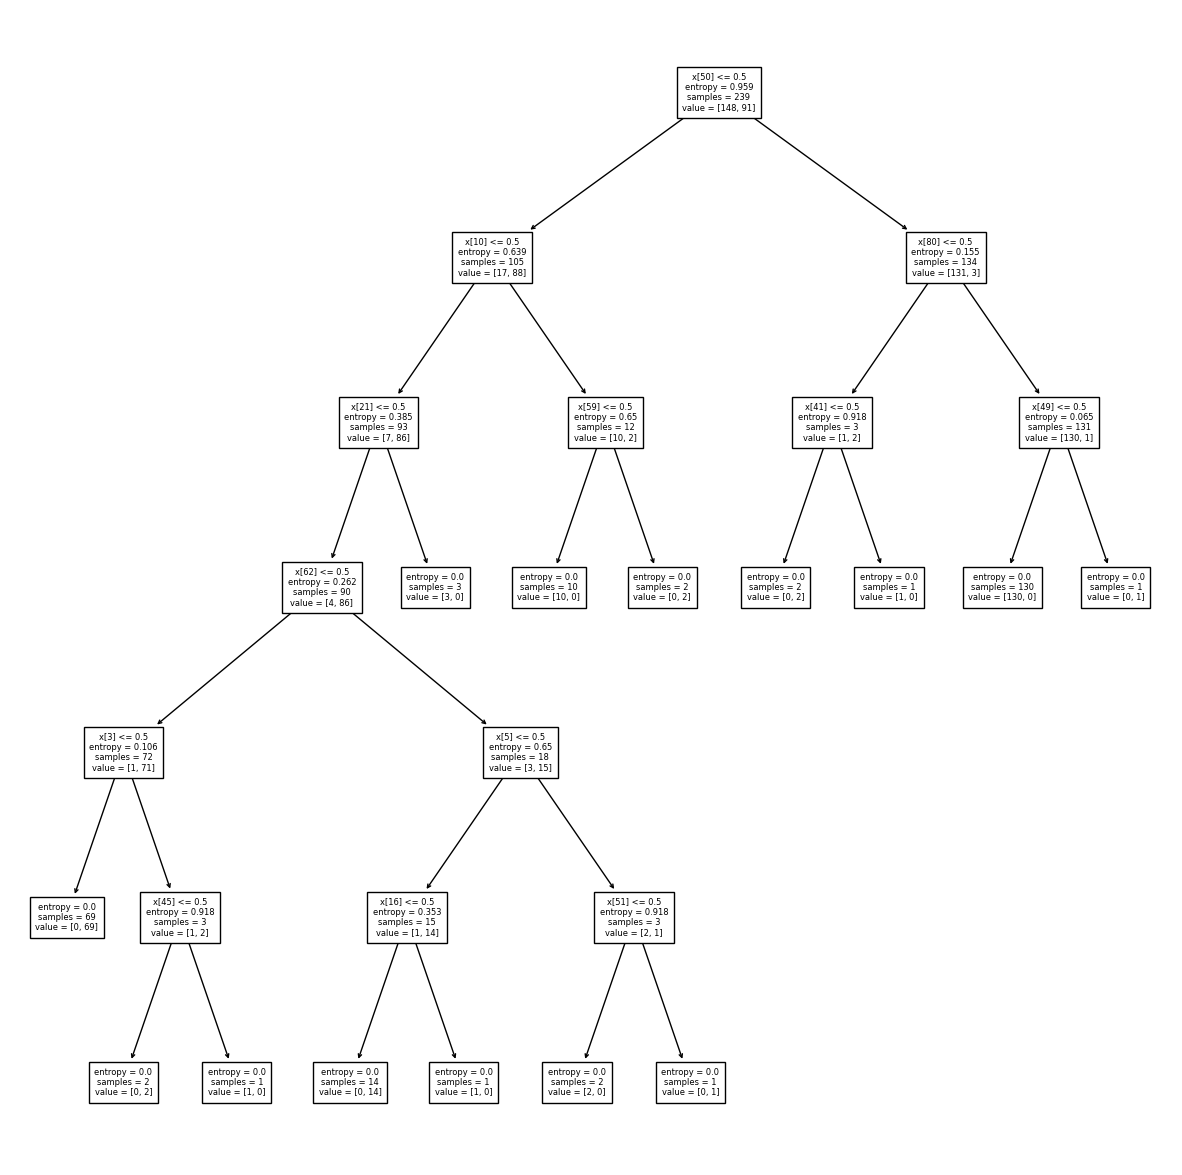

In [177]:
plt.figure(figsize=(15,15))
tree.plot_tree(dtree, fontsize=6)
plt.show()

Comparaison du taux d'erreur de prédiction avec :
- les données d'entraînement `X_train` qui ont servi à construire l'arbre de décision
- les données de test `X_test` qui n'ont jamais été utilisées

In [178]:
error_train = sum(dtree.predict(X_train)!= y_train)/y_train.size
#error petit sur entrainement normal
error_test = sum(dtree.predict(X_test)!= y_test)/y_test.size
#base de test pour évaluer, important, si petit comme error c'est que c'est bon
#overfitting= on est trop adapté sur données d'entrainement a chaque fois que on fait de nv test ca ne fonctionne pas
error_train, error_test


(0.0, 0.058577405857740586)

resultat: (0.0, 0.10460251046025104)

On peut voir que le taux d'erreur sur la base d'entrainement et de 0 et que le taux d'erreur de la base de Test est également très bas (environ 0.105). Le taux d'erreur est assez similaire à la base d'entrainement, donc le modèle est bon

<function matplotlib.pyplot.show(close=None, block=None)>

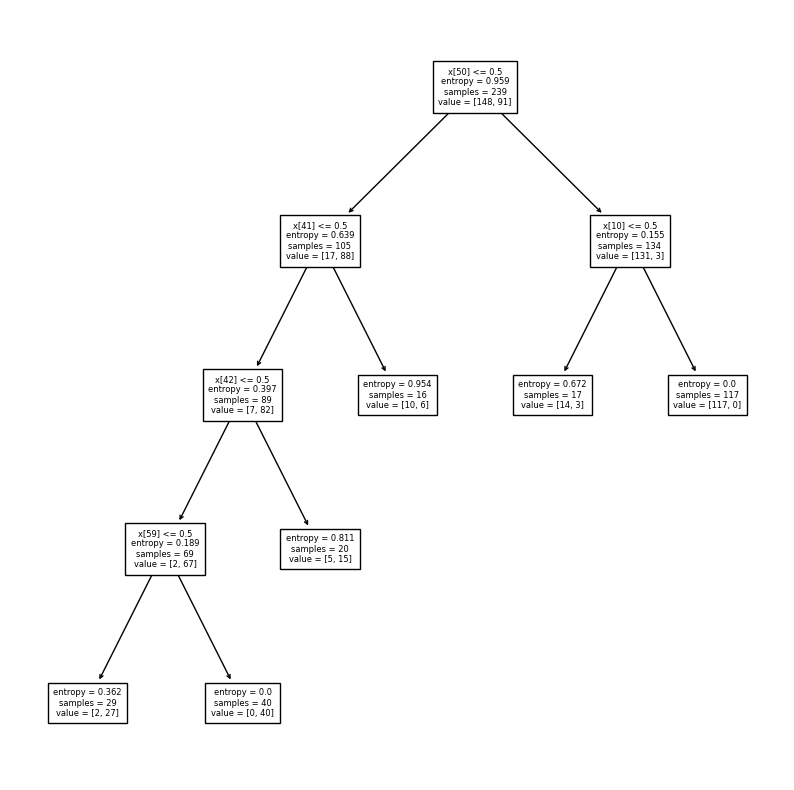

In [179]:
from pytest import yield_fixture




dtree_shallower= tree.DecisionTreeClassifier(criterion="entropy", min_samples_leaf=15)
dtree_shallower.fit(X_train, y_train)


plt.figure(figsize=(10,10))
tree.plot_tree(dtree_shallower, fontsize=6)
plt.show

Arbre de décision crée

retourne l'erreur d'apprentissage et l'erreur de généralisation d'un arbre de décision de profonduer contrôlée par `min_samples_leaf`, appris sur `X_train` et testé sur `X_test`.

In [180]:
def eval_DT(X_train, y_train, X_test, y_test, min_samples_leaf):
    dtree = tree.DecisionTreeClassifier(criterion="entropy", min_samples_leaf=min_samples_leaf)
    dtree = dtree.fit(X_train, y_train)
    train_error = sum(dtree.predict(X_train)!= y_train)/y_train.size
    test_error = sum(dtree.predict(X_test)!= y_test)/y_test.size
    return train_error, test_error

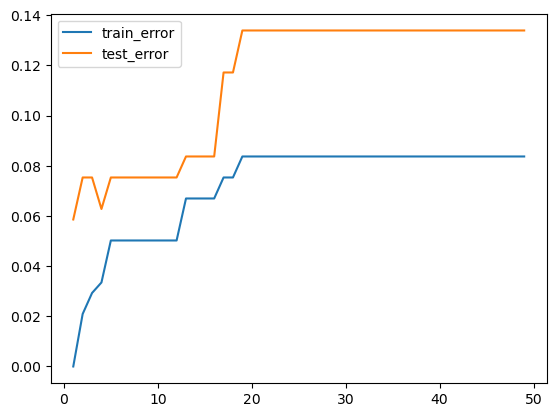

In [181]:
func= lambda x: eval_DT(X_train, y_train, X_test, y_test, min_samples_leaf=x)
res = np.array([func(x) for x in range(1,50)])
#from cProfile import label

import matplotlib.pyplot as plt
plt.plot(range(1,50), res [:,0], label= "train_error")
plt.plot(range(1,50), res [:,1], label= "test_error")

plt.legend()
plt.show()

En analysant le graphe obtenue, je peux voir que le plus petit taux d'erreur de test est d'environ 13
et que le plus petit taux d'erreur d'entrainement est de 6

## Votre modèle final

In [182]:
# définissez ici le modèle que vous aurez finalement choisi
model = dtree

In [187]:
# prédictions de votre modèle sur de nouvelles données
import pandas as pd
eval_set = pd.read_csv('donnees/breast_cancer_eval.csv')  # ne pas modifier cette ligne

# votre traitement sur eval_set (à adapter)
X_test = np.array(eval_set)
predictions = model.predict(X_train)

In [ ]:
# cadre réservé à votre enseignant pour l'évaluation des prédictions de votre modèle
# 
# 